In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('generalization_exp.csv')

initial_metrics = {
    "COPDGene": 23.36,
    "HCP": 53.4,
    "OAI": 7.6,
    "l2r_abdomenCTCT": 25.9
}

# df = df[(df['model'] == 'unigradicon') & (df['dataset'] == 'COPDGene')]

Legend


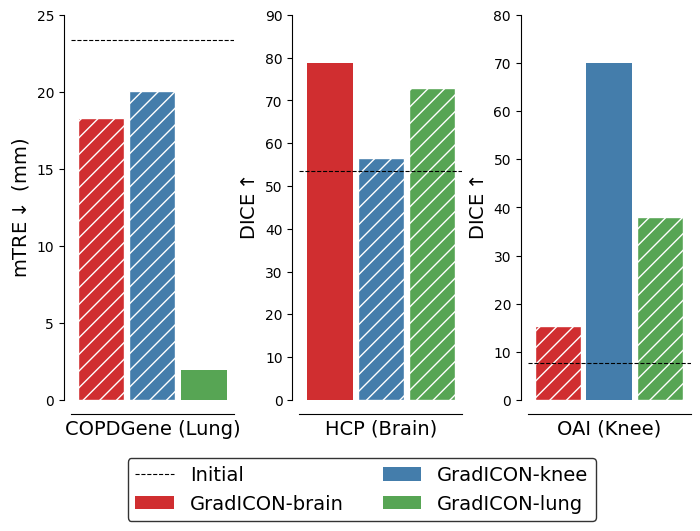

In [7]:
from matplotlib.colors import to_rgb
import pandas as pd 
import seaborn as sns
import matplotlib.gridspec as gridspec

sns.set_palette("Set1")

# Set the style to 'seaborn' for a cleaner look
# plt.style.use('seaborn')

fig = plt.figure(figsize=(8, 5))
gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1,1])
font_size = 14

df_to_plot = df[(df['IO'] == 0) & (df['shape'] == 'as_model') & (df['model'] != 'unigradicon') & (df['dataset'] != 'l2r_abdomenCTCT')]
df_to_plot = df_to_plot.sort_values(by=['dataset', 'model'])

# Get the unique datasets and models
datasets = df_to_plot['dataset'].unique()
models = df_to_plot['model'].unique()
io = df_to_plot['IO'].unique()
shape = df_to_plot['shape'].unique()

# Set bar width and x positions
bar_width = 0.05
x = np.arange(len(datasets))

# Define base colors and adjust gray level
base_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#ADB2D4', '#A5158C']  # Original colors (blue, orange, green)

# Function to adjust color towards gray (desaturate)
def adjust_to_gray(color, gray_level=0.7):
    rgb = np.array(to_rgb(color))  # Convert to RGB tuple
    gray = np.array([gray_level] * 3)  # Gray RGB tuple (same R, G, B values)
    return rgb * (1 - gray_level) + gray * gray_level  # Blend the original color with gray

# Apply the adjust_to_gray function to each color
gray_adjusted_colors = [adjust_to_gray(c, gray_level=0.8) for c in base_colors]

# Create a figure and axes
# fig, ax = plt.subplots()

for j, dataset in enumerate(datasets):
    ax = plt.subplot(gs[0,j])
    model_data = df_to_plot[(df_to_plot['dataset'] == dataset) & (df_to_plot['IO'] == 0)]
    if dataset == "COPDGene":
        metric = "mTRE"
        ax.set_ylabel(r"mTRE$\downarrow$ (mm)", fontsize=font_size)
    else:
        metric = "DICE"
        ax.set_ylabel(r"DICE$\uparrow$", fontsize=font_size)

    # Plot the initial metrics
    ax.axhline(y=initial_metrics[dataset], color='black', linestyle='--', label='Initial', linewidth=0.8)

    # Plot the data
    ax = sns.barplot(model_data, x="dataset", y=metric, hue="model", gap=0.1, ax=ax, width=0.5, saturation=0.8)
    ax.legend().set_visible(False)

    if dataset == "COPDGene":
        ax.set_ylim([0, 25])
    elif dataset == "HCP":
        ax.set_ylim([0, 90])
    elif dataset == "OAI":
        ax.set_ylim([0, 80])
    ax.set_xticks([])
    
    
    # Adjust the style
    bars = ax.patches

    # Iterate through the bars and set the edge style based on hue
    hue_type = model_data['model'].unique()
    num_hue_groups = len(hue_type)

    # Example
    # hatches = ["//", "\\\\", "|"]
    # # Loop over the bars
    # for bars, hatch in zip(ax.containers, hatches):
    #     # Set a different hatch for each group of bars
    #     for bar in bars:
    #         bar.set_hatch(hatch)

    for i, bar in enumerate(bars):
        hue_value = hue_type[i % num_hue_groups]  # Get the hue value
        if model_data[model_data['model'] == hue_value]["OOD"].values[0] == 1:
            ax.patches[i].set_hatch('//')
            ax.patches[i].set_edgecolor('white')
            # bar.set_linestyle('--')
            # bar.set_edgecolor('black')
            # bar.set_linewidth(1.5)
        # bar.set_facecolor(gray_adjusted_colors[i % len(gray_adjusted_colors)])  # Set the color of each bar
    
    label_texts = {
        "COPDGene": "COPDGene (Lung)",
        "HCP": "HCP (Brain)",
        "OAI": "OAI (Knee)",
    }
    ax.set_xlabel(f"{label_texts[dataset]}", fontsize=font_size)

    ax.relim()
    ax.autoscale_view()
    ax.margins(y=0.01)
    # ax = plt.subplot(gs[1,j])
    # model_data = df[(df['dataset'] == dataset) & (df['IO'] == 50)]
    # ax = sns.barplot(model_data, x="dataset", y=metric, hue="model", gap=0.1, ax=ax)
    # ax.legend().set_visible(False)
    # ax.set_ylabel(metric)

    # Set labels and title
    # ax.set_xlabel('Datasets')
    
    # ax.set_title('DICE Scores by Dataset and Model')
    # ax.set_xticks(x + (i*2+1)*bar_width)
    # ax.set_xticklabels(datasets)

# Add a legend
ax.legend().set_visible(True)
sns.move_legend(ax, frameon=True, facecolor='white', edgecolor='black',
                title="", ncol=2, bbox_to_anchor=(-2.5, -0.13), loc='upper left', fontsize=font_size, borderaxespad=0.4)

# Get the legend object
legend = ax.get_legend()

legend_texts = {
    "brain": "GradICON-brain",
    "lung": "GradICON-lung",
    "knee": "GradICON-knee",
}
texts = legend.get_texts()
for legend_text in texts:
    if legend_text.get_text() in legend_texts:
        legend_text.set_text(legend_texts[legend_text.get_text()])

print(legend)
# Iterate through the legend handles (patches) and remove their edges
for handle in legend.legend_handles[1:]:
    handle.set_edgecolor('none')
    handle.set_hatch('//')

plt.subplots_adjust(wspace=0.4, hspace=0.4)

sns.despine(offset=(5,10), trim=True)

# Display the plot
# plt.tight_layout()

# plt.show()

plt.savefig('figures/01_generalization_exp.png', bbox_inches='tight', dpi=200, bbox_extra_artists=(legend,))